In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-02-16 16:19:57.937506


In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
# plt.rcdefaults()

In [4]:
# plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams['figure.figsize'] = (3,3)
# plt.rcParams["figure.dpi"] = 300

In [5]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [6]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

base_dir = BASE_DIR 

input_dir = BASE_DIR / "data/h5ad/export_04/04c_gamma_subtypes"
thresholds_dir = BASE_DIR / "data/h5ad/export_05/05a_thresholds"

# global adata
adata_global_path = base_dir / "data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad"

# neuron adata
adata_path = input_dir / 'neurons-final-labels.h5ad' # using 1000 transcripts/cell filtering, final neuron_label

# cgrp gamma subset adata
gamma_adata_path = input_dir / 'cgrp-gamma-final-labels.h5ad'

# reporter status table
reporters_path = thresholds_dir / "reporter_classes_gaussian_thresholds.csv"


In [7]:
output_dir = os.path.join(base_dir, "figures_tables")

plot_out_dir = os.path.join(output_dir, "plots")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

In [8]:
print(base_dir)

/home/workspace/DRG/spatial_mouse_drg_outputs/yano


In [9]:
adata_global = sc.read_h5ad(adata_global_path)

In [10]:
adata = sc.read_h5ad(adata_path)

In [11]:
gamma_adata = sc.read_h5ad(gamma_adata_path)

## Plotting functions

In [12]:
import matplotlib.pyplot as plt

def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
    save_path  = None
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(os.path.join(save_path, f"umap_{col}.pdf"), format='pdf', bbox_inches='tight')

        plt.show()

In [13]:
def barplot_dual_distribution(
    adata,
    population_name,
    group_col="neuron_label",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 4),
    fontsize=11,
    plot_counts = True,
    return_group_order=False,
    group_order=None,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()
    print('number +: ', total_dual)

    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    if group_order is not None:
        # Use the provided order. .reindex ensures we handle missing/extra groups safely.
        # Fill missing groups with 0 so the bars show up as empty instead of crashing.
        stats = stats.reindex(group_order).fillna(0)
    else:
        # Default: Sort by percentage descending
        stats = stats.sort_values(ascending=False)
    
    # Final order of categories
    final_order = stats.index.tolist()
    sorted_counts = dual_counts.reindex(final_order).fillna(0)

    # # ordered counts
    # sorted_counts = dual_counts.loc[stats.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    if plot_counts:
        ax.bar(x, sorted_counts.values, color=bar_color, alpha=0.9)
    else:
        ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    if plot_counts:
        ax.set_ylabel("Count", fontsize=fontsize)
    else:     
        ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
        ax.set_ylabel(f"% of {population_name} \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    if return_group_order:
        return fig, final_order
    return fig

## Add reporter status to adata

In [14]:
reporter_classes_updated_dual = pd.read_csv(reporters_path, index_col = 0)
reporter_classes_updated_dual.head()

,sample_id,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aaaacmnk-1-0,TMA00316,False,False,False,Negative
aaababeb-1-0,TMA00316,False,False,False,Negative
aaaegioj-1-0,TMA00316,False,False,False,Negative
aadidbcn-1-0,TMA00316,False,False,False,Negative
aaeepbcc-1-0,TMA00316,False,False,False,Negative


In [15]:
# add individual reporter columns
adata.obs = adata.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])



In [16]:
# add individual reporter columns
gamma_adata.obs = gamma_adata.obs.join(reporter_classes_updated_dual[['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi', 'reporter_status']])

## Confirm key aspects of processed dataset

In [17]:
# neurons where thresholded at 1000 transcripts/cell
min(adata.obs['total_counts'])

1000.0

## Check reporters

In [18]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,9823
1,True,False,False,395
2,False,True,False,55
3,True,True,True,3


In [19]:
counts_series = adata.obs.value_counts(['reporter_status'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,reporter_status,cell_count
0,Negative,9823
1,EGFP_Seq1_hi,395
2,dTomato_Seq2_hi,55
3,EGFP_dTomato_dual_hi,3


## Check global adata

In [23]:
np.min(adata_global.obs['total_counts'])

51.0

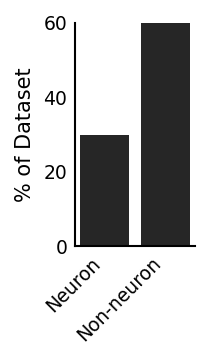

In [22]:
## plot neuron vs non-neuron fraction

# Count total and neuron fraction
counts = adata_global.obs["cell_class"].value_counts()

neuron_count = counts.get("Neuron", 0)
total = counts.sum()
non_neuron_count = total - neuron_count

# Percentages
labels = ["Neuron", "Non-neuron"]
values = [(neuron_count / total) * 100,
          (non_neuron_count / total) * 100]

# --- Minimal plot ---
plt.figure(figsize=(1.5, 2.5), dpi=150)
plt.bar(labels, values, color=["black", "black"], alpha=0.85)   # <-- both gray

# Style: minimalist
plt.ylim(0, 60)
plt.ylabel("% of Dataset", fontsize=10)
plt.xlabel("")
plt.xticks(rotation=45, ha='right', fontsize=9)   # <-- rotated x labels
plt.yticks(fontsize=9)

# Only bottom & left spine
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1)
ax.spines['bottom'].set_linewidth(1)

# No tick marks
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig(os.path.join(plot_out_dir, f"neuron_non-neuron_fraction.pdf"), format='pdf', bbox_inches='tight')

## Check Umaps

## Xenium

In [21]:
labels = ["Negative", "EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "Negative": "grey",
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


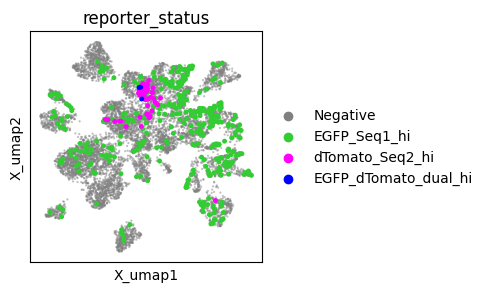

In [22]:

sc.pl.embedding(adata[adata.obs['reporter_status']=='Negative'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 0.5, size = 10, show=False)
ax = plt.gca()
sc.pl.embedding(adata[adata.obs['reporter_status']=='EGFP_Seq1_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=False)
sc.pl.embedding(adata[adata.obs['reporter_status']=='dTomato_Seq2_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=False)
sc.pl.embedding(adata[adata.obs['reporter_status']=='EGFP_dTomato_dual_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=True)



/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/anndata/_core/anndata.py:1145: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


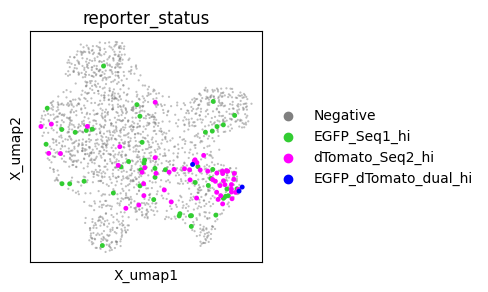

In [27]:
sc.pl.embedding(gamma_adata[gamma_adata.obs['reporter_status']=='Negative'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 0.5, size = 10, show=False)
ax = plt.gca()
sc.pl.embedding(gamma_adata[gamma_adata.obs['reporter_status']=='EGFP_Seq1_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=False)
sc.pl.embedding(gamma_adata[gamma_adata.obs['reporter_status']=='dTomato_Seq2_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=False)
sc.pl.embedding(gamma_adata[gamma_adata.obs['reporter_status']=='EGFP_dTomato_dual_hi'], basis = 'X_umap', color = 'reporter_status', palette = true_color_map, alpha = 1, ax=ax, size=50, show=True)


Column `Negative` not in adata.obs — skipping.


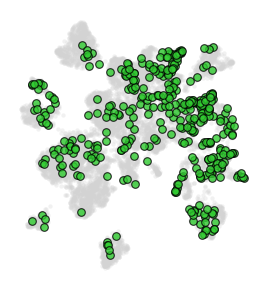

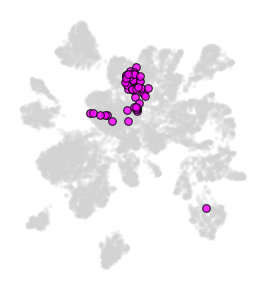

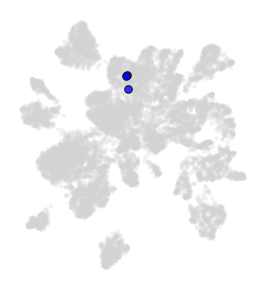

In [28]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
    save_path = plot_out_dir
)

## Check reporter status and bar plots

In [29]:
group_col = 'neuron_label'
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]
for dual_col in labels:
    # output 
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")
    
    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()
    
    total_dual = dual_counts.sum()
    print('number +: ', total_dual)
    
    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)
    
    count_percent_df = pd.concat([dual_counts, stats], axis=1)
    count_percent_df.columns = ['count', 'percent']
    count_percent_df = count_percent_df.sort_values(by='percent', ascending=False)
    print(count_percent_df)

number +:  398
                            count    percent
neuron_label                                
CGRP-Eta                       67  16.834171
Abeta-RA-LTMR                  52  13.065327
CGRP-Zeta                      48  12.060302
Abeta-Field                    46  11.557789
Nonpeptidergic nociceptors     36   9.045226
Proprioceptors                 33   8.291457
CGRP-Gamma 1                   25   6.281407
CGRP-Gamma 2                   25   6.281407
CGRP-Theta                     24   6.030151
C-LTMR                          8   2.010050
CGRP-Alpha                      8   2.010050
Adelta-LTMR                     7   1.758794
TrpM8                           7   1.758794
CGRP-Epsilion                   6   1.507538
Sst                             6   1.507538
CGRP-Beta                       0   0.000000
number +:  58
                            count    percent
neuron_label                                
CGRP-Gamma 2                   38  65.517241
CGRP-Gamma 1              

In [30]:
# Show single+ all together
counts_series = adata.obs.value_counts(['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi'])
counts_df = counts_series.reset_index(name='cell_count')
counts_df

,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,cell_count
0,False,False,False,9823
1,True,False,False,395
2,False,True,False,55
3,True,True,True,3


In [31]:
adata.obs['reporter_status'].unique().tolist()

['Negative', 'EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']

In [32]:
counts = adata.obs.value_counts(['reporter_status'])
counts

reporter_status     
Negative                9823
EGFP_Seq1_hi             395
dTomato_Seq2_hi           55
EGFP_dTomato_dual_hi       3
Name: count, dtype: int64

In [33]:
counts = adata.obs.value_counts(['EGFP_Seq1_hi'])
counts

EGFP_Seq1_hi
False           9878
True             398
Name: count, dtype: int64

In [34]:
counts = adata.obs.value_counts(['dTomato_Seq2_hi'])
counts

dTomato_Seq2_hi
False              10218
True                  58
Name: count, dtype: int64

In [35]:
counts = adata.obs.value_counts(['EGFP_dTomato_dual_hi'])
counts

EGFP_dTomato_dual_hi
False                   10273
True                        3
Name: count, dtype: int64

### Export reporter status counts as csv
We will make four versions of these csvs
1. Counts of reporter positive cells where the EGFP+ and dTomato+ counts are not single positive (e.g. they include that dual+ cells)
2. Counts of reporter positive cells where the EGFP+ and dTomato+ counts are single positive
3. For each of these 2 options, generate the table first with counts separated by cell type and then collapsed to combine all cell types

### Csvs for single positives
Use, 'reporter status' column, which already contains single+ and dual+

In [36]:
# counts by neuron label
combined_counts = adata.obs.value_counts(['neuron_label', 'reporter_status'])

combined_df = combined_counts.reset_index(name='cell_count')

# # 3. Apply your rename_map to the reporter_status column
# combined_df['reporter_status'] = combined_df['reporter_status'].map(rename_map)

# Sort for better readability (Group by neuron, then descending count)
combined_df = combined_df.sort_values(['neuron_label', 'cell_count'], ascending=[True, False])

# now collapse cell types
combined_df_collapse = combined_df.groupby('reporter_status')['cell_count'].sum().reset_index().sort_values(by='cell_count', ascending=False)

# Export
combined_df.to_csv(os.path.join(output_dir, 'neuron_label_reporter_status_single_positive.csv'), index=False)
combined_df_collapse.to_csv(os.path.join(output_dir, 'all_neurons_reporter_status_single_positive.csv'), index=False)

In [37]:
combined_df.head()

,neuron_label,reporter_status,cell_count
6,Abeta-Field,Negative,512
19,Abeta-Field,EGFP_Seq1_hi,46
7,Abeta-RA-LTMR,Negative,499
17,Abeta-RA-LTMR,EGFP_Seq1_hi,52
11,Adelta-LTMR,Negative,371


In [38]:
combined_df_collapse

,reporter_status,cell_count
2,Negative,9823
0,EGFP_Seq1_hi,395
3,dTomato_Seq2_hi,55
1,EGFP_dTomato_dual_hi,3


### Csvs for all reporter positives (not requiring single positive)

Use the individual reporter True/False columns for counting

In [39]:
# counts by neuron label
single_reporter_cols = ['EGFP_Seq1_hi', 'dTomato_Seq2_hi', 'EGFP_dTomato_dual_hi']
combined_counts = adata.obs.groupby('neuron_label')[single_reporter_cols].sum()
is_negative = adata.obs[single_reporter_cols].sum(axis=1) == 0
combined_counts['Negative'] = adata.obs[is_negative].groupby('neuron_label').size()


# Reshape from "Wide" to "Long" format 
combined_df = combined_counts.stack().reset_index()

# relabel columns
combined_df.columns = ['neuron_label', 'reporter_status', 'cell_count']

# sort
combined_df = combined_df.sort_values(['neuron_label', 'cell_count'], ascending=[True, False])

# now collapse cell types
combined_df_collapse = combined_df.groupby('reporter_status')['cell_count'].sum().reset_index().sort_values(by='cell_count', ascending=False)

# Export
combined_df.to_csv(os.path.join(output_dir, 'neuron_label_reporter_status_not_single_positive.csv'), index=False)
combined_df_collapse.to_csv(os.path.join(output_dir, 'all_neurons_reporter_status_not_single_positive.csv'), index=False)

/tmp/ipykernel_4261/3776613712.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_counts = adata.obs.groupby('neuron_label')[single_reporter_cols].sum()
/tmp/ipykernel_4261/3776613712.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_counts['Negative'] = adata.obs[is_negative].groupby('neuron_label').size()


In [40]:
combined_df

,neuron_label,reporter_status,cell_count
3,Abeta-Field,Negative,512
0,Abeta-Field,EGFP_Seq1_hi,46
1,Abeta-Field,dTomato_Seq2_hi,0
2,Abeta-Field,EGFP_dTomato_dual_hi,0
7,Abeta-RA-LTMR,Negative,499
...,...,...,...
58,Sst,EGFP_dTomato_dual_hi,0
63,TrpM8,Negative,396
60,TrpM8,EGFP_Seq1_hi,7
61,TrpM8,dTomato_Seq2_hi,0


In [41]:
combined_df_collapse

,reporter_status,cell_count
2,Negative,9823
0,EGFP_Seq1_hi,398
3,dTomato_Seq2_hi,58
1,EGFP_dTomato_dual_hi,3


### Plot reporter status barplots

### Counts - showing reporter+ (not necessarily single positive)

number +:  3
number +:  398
number +:  58


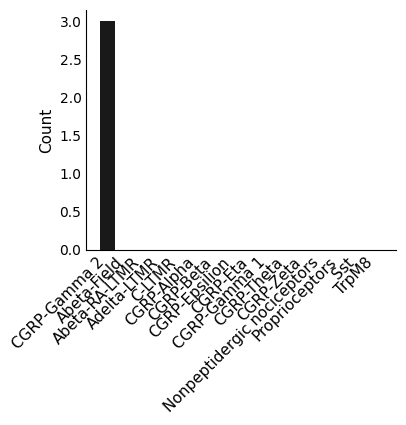

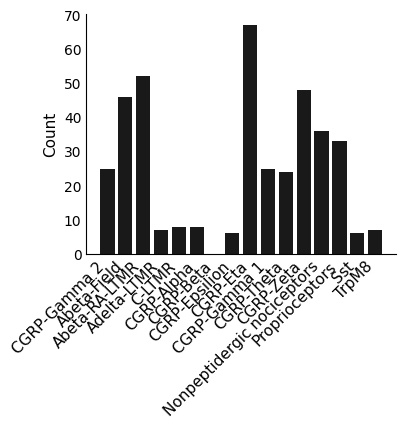

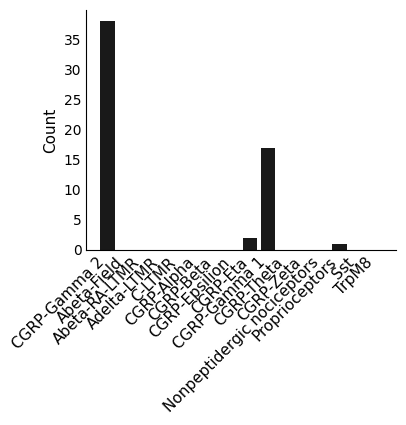

In [42]:
# set cell type order based on dual positive order
_, dual_order = barplot_dual_distribution(adata, population_name = 'Double+',
                                          dual_col="EGFP_dTomato_dual_hi",
                          return_group_order=True,
                            group_order=None)   
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'EGFP+',
                          dual_col="EGFP_Seq1_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata,population_name = 'dTomato+',
                          dual_col="dTomato_Seq2_hi",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count.pdf"), format='pdf', bbox_inches='tight')



### Counts - showing single positive only for each single reporter

number +:  395
number +:  55


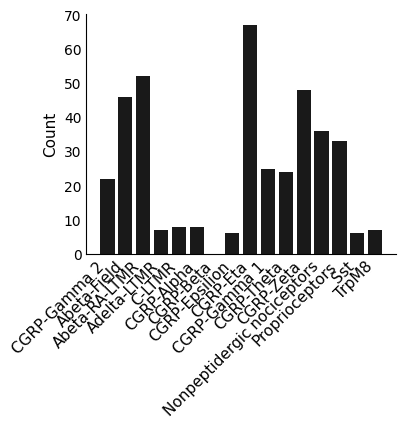

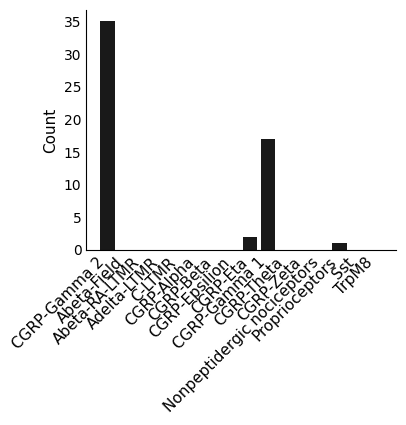

In [43]:
# set cell type order based on dual positive order

# make new temporary column 
tmp = adata.copy()
tmp.obs['EGFP_single_positive'] = False
tmp.obs['dTomato_single_positive'] = False
tmp.obs.loc[tmp.obs['reporter_status']=='EGFP_Seq1_hi', 'EGFP_single_positive'] = True
tmp.obs.loc[tmp.obs['reporter_status']=='dTomato_Seq2_hi', 'dTomato_single_positive'] = True

barplot_dual_distribution(tmp,population_name = 'EGFP+',
                          dual_col="EGFP_single_positive",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_count_single_positive.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(tmp,population_name = 'dTomato+',
                          dual_col="dTomato_single_positive",
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_count_single_positive.pdf"), format='pdf', bbox_inches='tight')



### Percent - showing reporter+ (not single positive)

number +:  3
number +:  398
number +:  58


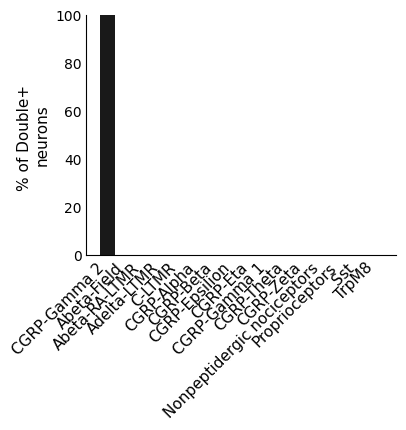

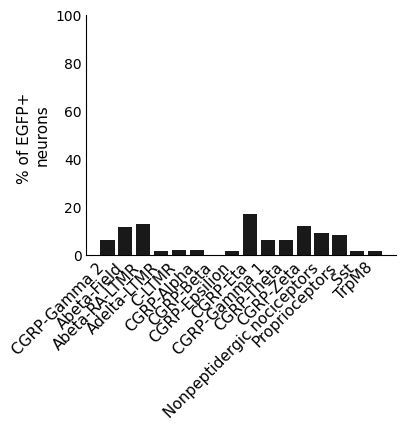

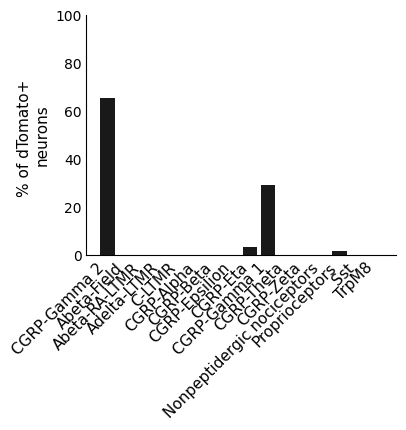

In [44]:
# use cell label ordering from dual+ counts plot above
barplot_dual_distribution(adata, population_name = 'Double+',
                          dual_col="EGFP_dTomato_dual_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dual_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata, population_name = 'EGFP+', 
                          dual_col="EGFP_Seq1_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(adata, population_name = 'dTomato+', 
                          dual_col="dTomato_Seq2_hi", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_percent.pdf"), format='pdf', bbox_inches='tight')

### Percent - showing single positive only

number +:  395
number +:  55


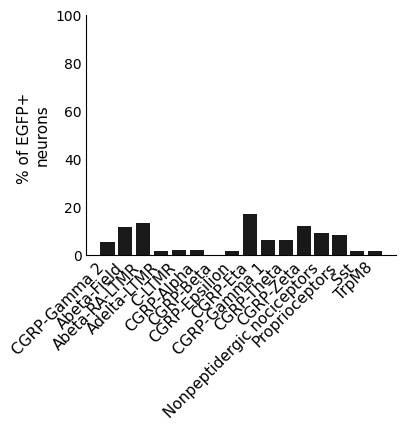

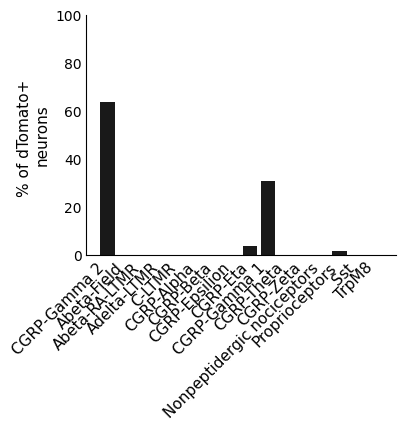

In [45]:
# set cell type order based on dual positive order

# make new temporary column 
tmp = adata.copy()
tmp.obs['EGFP_single_positive'] = False
tmp.obs['dTomato_single_positive'] = False
tmp.obs.loc[tmp.obs['reporter_status']=='EGFP_Seq1_hi', 'EGFP_single_positive'] = True
tmp.obs.loc[tmp.obs['reporter_status']=='dTomato_Seq2_hi', 'dTomato_single_positive'] = True

barplot_dual_distribution(tmp,population_name = 'EGFP+',
                          dual_col="EGFP_single_positive", plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "EGFP_distribution_percent_single_positive.pdf"), format='pdf', bbox_inches='tight')

barplot_dual_distribution(tmp,population_name = 'dTomato+',
                          dual_col="dTomato_single_positive",plot_counts = False,
                         group_order = dual_order)
plt.savefig(os.path.join(plot_out_dir, "dTomato_distribution_percent_single_positive.pdf"), format='pdf', bbox_inches='tight')



## Save label and reporter outputs for xenium explorer

In this adata object, the cell barcodes do not seen to have a suffix indicating the sample number. However, it looks like all indices are still unique. 

In [46]:
adata.obs.index.is_unique

True

In [47]:
adata.obs.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Fibroblast_1,prediction.score.max,cell_type,cell_class,neuron_recluster,neuron_label,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aagiofkl-1-0,aagiofkl-1,659.230835,3544.038574,4306,0,0,0,0,0,4306.0,...,0.0,0.657502,Abeta-RA-LTMR,Neuron,6,Abeta-RA-LTMR,False,False,False,Negative
aagjepdf-1-0,aagjepdf-1,700.395691,3534.279053,4150,1,0,0,0,0,4150.0,...,0.0,0.981951,Proprioceptors,Neuron,10,Proprioceptors,False,False,False,Negative
aagnchan-1-0,aagnchan-1,706.977844,3597.092529,2223,1,0,0,0,0,2223.0,...,0.0,0.523645,Adelta-LTMR,Neuron,9,Adelta-LTMR,False,False,False,Negative
aahbfdme-1-0,aahbfdme-1,708.948425,3580.387207,1136,0,0,0,0,0,1136.0,...,0.0,0.821263,Nonpeptidergic nociceptors,Neuron,0,Nonpeptidergic nociceptors,False,False,False,Negative
aahiadbb-1-0,aahiadbb-1,735.618774,3544.880615,3582,0,0,0,0,0,3582.0,...,0.0,0.823615,Adelta-LTMR,Neuron,9,Adelta-LTMR,False,False,False,Negative


In [48]:
adata.obs['sample_id'].unique().tolist()

['TMA00316', 'TMA00318', 'TMA00317', 'TMA00315']

In [49]:
label_cols = ["cell_id","sample_id","neuron_label","EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi", "reporter_status"]
label_df = adata.obs[label_cols]

In [50]:
# which samples contain dual+?
counts = label_df.value_counts(['sample_id', 'EGFP_dTomato_dual_hi'])
counts

sample_id  EGFP_dTomato_dual_hi
TMA00315   False                   2808
TMA00316   False                   2796
TMA00318   False                   2366
TMA00317   False                   2303
TMA00316   True                       2
TMA00318   True                       1
Name: count, dtype: int64

In [51]:
label_df.head()

,cell_id,sample_id,neuron_label,EGFP_Seq1_hi,dTomato_Seq2_hi,EGFP_dTomato_dual_hi,reporter_status
aagiofkl-1-0,aagiofkl-1,TMA00316,Abeta-RA-LTMR,False,False,False,Negative
aagjepdf-1-0,aagjepdf-1,TMA00316,Proprioceptors,False,False,False,Negative
aagnchan-1-0,aagnchan-1,TMA00316,Adelta-LTMR,False,False,False,Negative
aahbfdme-1-0,aahbfdme-1,TMA00316,Nonpeptidergic nociceptors,False,False,False,Negative
aahiadbb-1-0,aahiadbb-1,TMA00316,Adelta-LTMR,False,False,False,Negative


In [52]:
label_df['neuron_label'].unique().tolist()

['Abeta-RA-LTMR',
 'Proprioceptors',
 'Adelta-LTMR',
 'Nonpeptidergic nociceptors',
 'CGRP-Epsilion',
 'CGRP-Eta',
 'CGRP-Zeta',
 'C-LTMR',
 'CGRP-Alpha',
 'Abeta-Field',
 'CGRP-Theta',
 'CGRP-Gamma 1',
 'TrpM8',
 'Sst',
 'CGRP-Gamma 2',
 'CGRP-Beta']

### Output csvs with neuron label

In [53]:
# for Xenium explorer, can only have one group
label_df_neuron_label = label_df.copy()
label_df_neuron_label['group'] = label_df_neuron_label['neuron_label']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_neuron_label[label_df_neuron_label['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_neuron_label.csv"),index=False)

### Output csvs with reporter status

In [54]:
# for Xenium explorer, can only have one group
label_df_reporter = label_df.copy()
label_df_reporter['group'] = label_df_reporter['reporter_status']

# split to individual samples
for sample in adata.obs['sample_id'].unique().tolist():
    label_df_sample = label_df_reporter[label_df_reporter['sample_id']==sample]
    # save to csv 
    label_df_sample.to_csv(os.path.join(output_dir, f"label_df_{sample}_reporter.csv"),index=False)